In [1]:
import torch
from models.handler import Handler
from models.model import ResnetClassifier
from models.loss import FairLoss
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from torchvision import transforms
from torchvision.datasets import FashionMNIST, CIFAR10, CIFAR100, MNIST
from models.noise import InstanceDependentNoiseAdder

# Prepare

In [2]:
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
device

device(type='cuda')

In [3]:
train_dataset = CIFAR10(root='data', train=True, download=False)
noise_adder = InstanceDependentNoiseAdder(train_dataset, 0.2, 10)
noise_adder.add_noise()
test_dataset = CIFAR10(root='data', train=False, download=False)
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])

Seed: 48


# CE

In [4]:
model = ResnetClassifier()
model = model.to(device)
critertion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
handler = Handler(model, device, critertion, optimizer, train_dataset, test_dataset, transform)

Epoch 1/20: 100%|██████████| 352/352 [00:10<00:00, 35.10it/s, avg_loss=0.802, accuracy=0.528]


Epoch 1/20, Val Loss: 1.3616, Val Acc: 0.5554
Checkpoint saved at checkpoints/best_model_epoch_1.pth


Epoch 2/20: 100%|██████████| 352/352 [00:09<00:00, 36.67it/s, avg_loss=0.653, accuracy=0.625]


Epoch 2/20, Val Loss: 1.2140, Val Acc: 0.6118
Checkpoint saved at checkpoints/best_model_epoch_2.pth


Epoch 3/20: 100%|██████████| 352/352 [00:09<00:00, 37.19it/s, avg_loss=0.593, accuracy=0.659]


...

Epoch 18/20, Val Loss: 2.2083, Val Acc: 0.5596


Epoch 19/20: 100%|██████████| 352/352 [00:09<00:00, 36.45it/s, avg_loss=0.0713, accuracy=0.956]


Epoch 19/20, Val Loss: 2.2641, Val Acc: 0.5708


Epoch 20/20: 100%|██████████| 352/352 [00:09<00:00, 36.08it/s, avg_loss=0.0639, accuracy=0.96] 


Epoch 20/20, Val Loss: 2.2834, Val Acc: 0.5778
Loaded checkpoint from checkpoints/best_model_epoch_4.pth at epoch 4
Best model loaded from checkpoints/best_model_epoch_4.pth with validation loss 1.1590


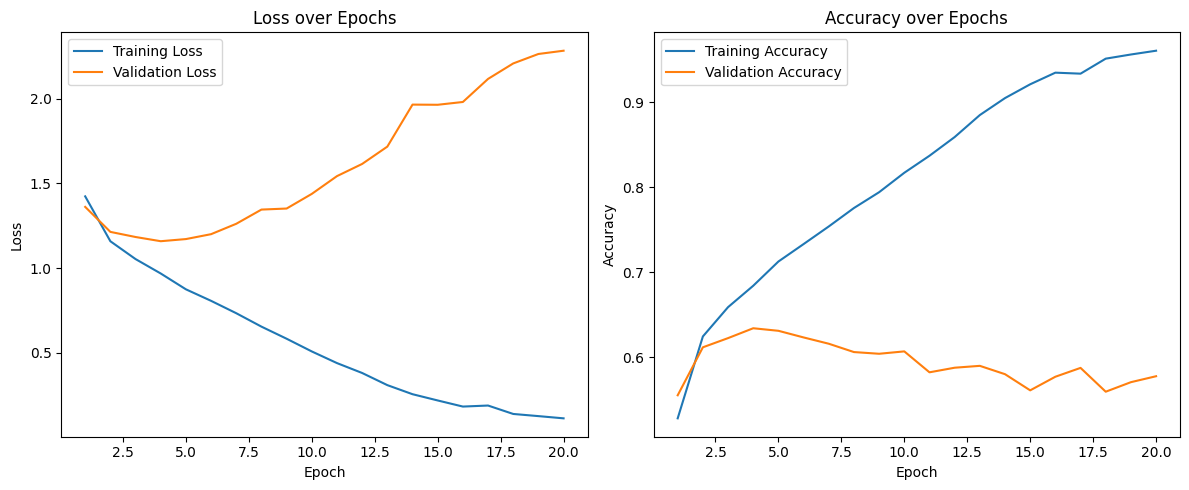

In [5]:
handler.train(20)

Testing: 100%|██████████| 157/157 [00:01<00:00, 125.28it/s]


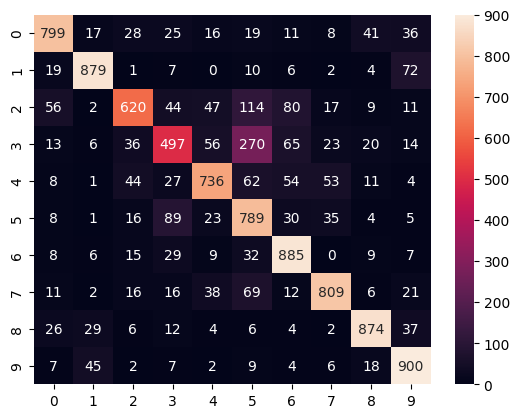


Classification Report:
              precision    recall  f1-score   support

           0    0.83665   0.79900   0.81739      1000
           1    0.88968   0.87900   0.88431      1000
           2    0.79082   0.62000   0.69507      1000
           3    0.66003   0.49700   0.56703      1000
           4    0.79055   0.73600   0.76230      1000
           5    0.57174   0.78900   0.66303      1000
           6    0.76890   0.88500   0.82287      1000
           7    0.84712   0.80900   0.82762      1000
           8    0.87751   0.87400   0.87575      1000
           9    0.81301   0.90000   0.85430      1000

    accuracy                        0.77880     10000
   macro avg    0.78460   0.77880   0.77697     10000
weighted avg    0.78460   0.77880   0.77697     10000



In [6]:
handler.test()

# Fair

In [7]:
model = ResnetClassifier()
model = model.to(device)
critertion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
handler = Handler(model, device, critertion, optimizer, train_dataset, test_dataset, transform)

Epoch 1/20: 100%|██████████| 352/352 [00:09<00:00, 37.12it/s, avg_loss=0.79, accuracy=0.535]


Epoch 1/20, Val Loss: 1.2653, Val Acc: 0.5946
Checkpoint saved at checkpoints/best_model_epoch_1.pth


Epoch 2/20: 100%|██████████| 352/352 [00:09<00:00, 36.70it/s, avg_loss=0.653, accuracy=0.624]


Epoch 2/20, Val Loss: 1.1697, Val Acc: 0.6180
Checkpoint saved at checkpoints/best_model_epoch_2.pth


Epoch 3/20: 100%|██████████| 352/352 [00:09<00:00, 36.91it/s, avg_loss=0.593, accuracy=0.659]


...

Epoch 18/20, Val Loss: 2.3103, Val Acc: 0.5654


Epoch 19/20: 100%|██████████| 352/352 [00:09<00:00, 36.76it/s, avg_loss=0.0783, accuracy=0.951]


Epoch 19/20, Val Loss: 2.1843, Val Acc: 0.5684


Epoch 20/20: 100%|██████████| 352/352 [00:09<00:00, 36.12it/s, avg_loss=0.0726, accuracy=0.954]


Epoch 20/20, Val Loss: 2.3268, Val Acc: 0.5612
Loaded checkpoint from checkpoints/best_model_epoch_3.pth at epoch 3
Best model loaded from checkpoints/best_model_epoch_3.pth with validation loss 1.1506


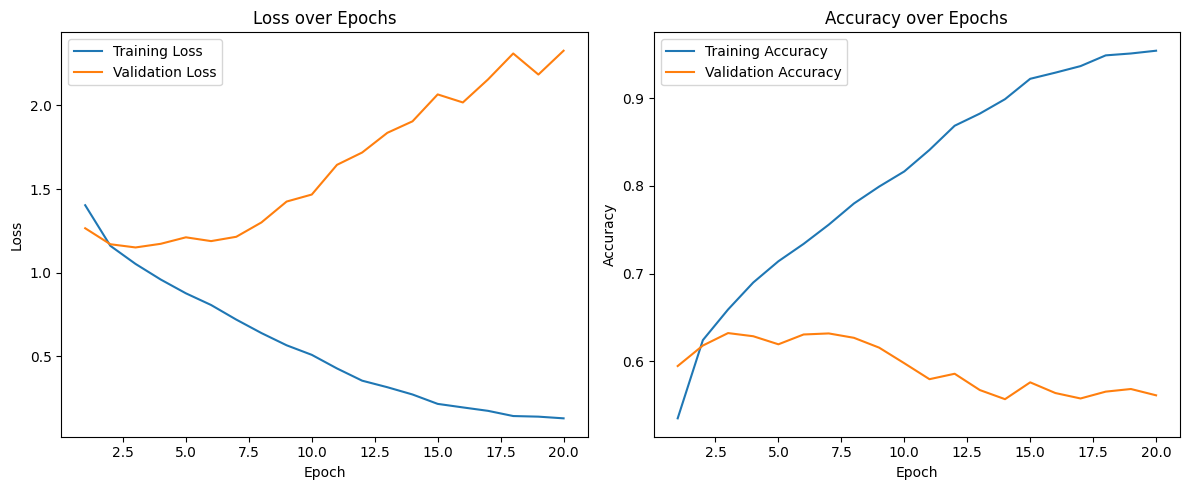

In [8]:
handler.train(20)

Testing: 100%|██████████| 157/157 [00:01<00:00, 118.22it/s]


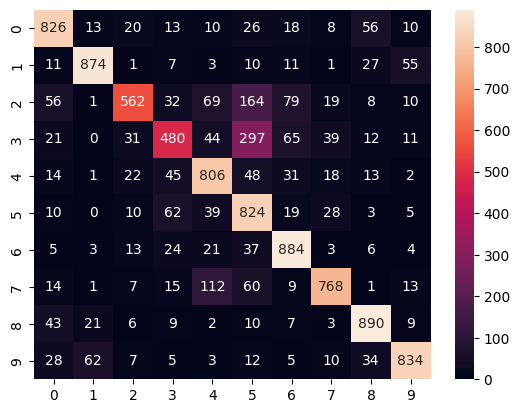


Classification Report:
              precision    recall  f1-score   support

           0    0.80350   0.82600   0.81460      1000
           1    0.89549   0.87400   0.88462      1000
           2    0.82769   0.56200   0.66945      1000
           3    0.69364   0.48000   0.56738      1000
           4    0.72678   0.80600   0.76434      1000
           5    0.55376   0.82400   0.66238      1000
           6    0.78369   0.88400   0.83083      1000
           7    0.85619   0.76800   0.80970      1000
           8    0.84762   0.89000   0.86829      1000
           9    0.87513   0.83400   0.85407      1000

    accuracy                        0.77480     10000
   macro avg    0.78635   0.77480   0.77256     10000
weighted avg    0.78635   0.77480   0.77256     10000



In [9]:
handler.test()